In [164]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [165]:
torch.manual_seed(42)

In [166]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_features = 6
output_size = 6
hidden_size = 20

seq_len = 20
batch_size = 16

learning_rate = 0.001
epochs = 150

tot_seq_size = 1000

In [167]:
#generating raw letter sequence
import random
seq=[]

for _ in range(tot_seq_size):
  a=random.choice(['b','d','g'])
  seq.append(a)

In [168]:
print(seq)

['b', 'd', 'g', 'b', 'g', 'g', 'd', 'b', 'g', 'b', 'd', 'b', 'b', 'g', 'g', 'd', 'd', 'd', 'd', 'd', 'd', 'b', 'b', 'b', 'g', 'g', 'd', 'd', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'd', 'd', 'b', 'g', 'g', 'd', 'd', 'b', 'd', 'b', 'g', 'g', 'd', 'b', 'g', 'g', 'b', 'b', 'g', 'g', 'd', 'b', 'b', 'd', 'd', 'g', 'b', 'b', 'g', 'g', 'g', 'd', 'b', 'g', 'g', 'd', 'd', 'b', 'd', 'g', 'b', 'b', 'd', 'g', 'b', 'd', 'g', 'g', 'd', 'g', 'd', 'b', 'd', 'd', 'g', 'g', 'g', 'd', 'g', 'd', 'b', 'b', 'g', 'g', 'g', 'd', 'd', 'b', 'g', 'd', 'b', 'b', 'g', 'b', 'b', 'g', 'b', 'g', 'b', 'b', 'g', 'g', 'b', 'b', 'g', 'g', 'd', 'b', 'g', 'g', 'd', 'd', 'b', 'g', 'g', 'd', 'b', 'd', 'd', 'b', 'g', 'b', 'd', 'g', 'd', 'b', 'b', 'b', 'g', 'b', 'd', 'b', 'd', 'g', 'g', 'g', 'd', 'g', 'g', 'd', 'd', 'g', 'd', 'd', 'd', 'd', 'd', 'd', 'b', 'g', 'b', 'b', 'g', 'g', 'g', 'g', 'b', 'd', 'b', 'd', 'g', 'b', 'd', 'b', 'd', 'd', 'd', 'd', 'b', 'd', 'b', 'd', 'b', 'b', 'b', 'b', 'b', 'g', 'g', 'd', 'b', 'g', 'b', 'g', 'b',

In [169]:
expanded_seq=[]
for c in seq:

    if c=='b':
        expanded_seq.extend(['b', 'a'])

    elif c=='d':
        expanded_seq.extend(['d', 'i', 'i'])

    elif c=='g':
        expanded_seq.extend(['g', 'u', 'u', 'u'])

print(expanded_seq)

['b', 'a', 'd', 'i', 'i', 'g', 'u', 'u', 'u', 'b', 'a', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'd', 'i', 'i', 'b', 'a', 'g', 'u', 'u', 'u', 'b', 'a', 'd', 'i', 'i', 'b', 'a', 'b', 'a', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'd', 'i', 'i', 'd', 'i', 'i', 'd', 'i', 'i', 'd', 'i', 'i', 'd', 'i', 'i', 'd', 'i', 'i', 'b', 'a', 'b', 'a', 'b', 'a', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'd', 'i', 'i', 'd', 'i', 'i', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'd', 'i', 'i', 'd', 'i', 'i', 'b', 'a', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'd', 'i', 'i', 'd', 'i', 'i', 'b', 'a', 'd', 'i', 'i', 'b', 'a', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'd', 'i', 'i', 'b', 'a', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'b', 'a', 'b', 'a', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'd', 'i', 'i', 'b', 'a', 'b', 'a', 'd', 'i', 'i', 'd', 'i', 'i', 'g', 'u', 'u', 'u', 'b', 'a', 'b', 'a', 'g', 'u', 'u', 'u', 'g', 'u',

In [170]:
input = expanded_seq[:-1]
target = expanded_seq[1:]

In [171]:
print(input)
print(target)

['b', 'a', 'd', 'i', 'i', 'g', 'u', 'u', 'u', 'b', 'a', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'd', 'i', 'i', 'b', 'a', 'g', 'u', 'u', 'u', 'b', 'a', 'd', 'i', 'i', 'b', 'a', 'b', 'a', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'd', 'i', 'i', 'd', 'i', 'i', 'd', 'i', 'i', 'd', 'i', 'i', 'd', 'i', 'i', 'd', 'i', 'i', 'b', 'a', 'b', 'a', 'b', 'a', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'd', 'i', 'i', 'd', 'i', 'i', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'd', 'i', 'i', 'd', 'i', 'i', 'b', 'a', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'd', 'i', 'i', 'd', 'i', 'i', 'b', 'a', 'd', 'i', 'i', 'b', 'a', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'd', 'i', 'i', 'b', 'a', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'b', 'a', 'b', 'a', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'd', 'i', 'i', 'b', 'a', 'b', 'a', 'd', 'i', 'i', 'd', 'i', 'i', 'g', 'u', 'u', 'u', 'b', 'a', 'b', 'a', 'g', 'u', 'u', 'u', 'g', 'u',

In [172]:
# integer encoding
char_to_idx = {'b': 0, 'd': 1, 'g': 2, 'a': 3, 'i': 4, 'u': 5}
idx_to_char = {0: 'b', 1: 'd', 2: 'g', 3: 'a', 4: 'i', 5: 'u'}

input = [char_to_idx[char] for char in input]
target = [char_to_idx[char] for char in target]

In [173]:
# 80% training and 20% testing
split_idx = int(0.8 * len(input))

train_input = input[:split_idx]
test_input = input[split_idx:]

train_target = target[:split_idx]
test_target = target[split_idx:]

In [174]:
#custom dataset class

class CustomDataset(Dataset):
  def __init__(self,input,target,seq_len):
    super().__init__()
    self.input=input
    self.target=target
    self.seq_len=seq_len

  def __len__(self):
    return len(self.input)-self.seq_len+1

  def __getitem__(self,sample):
    x=self.input[sample:sample+self.seq_len]
    y=self.target[sample:sample+self.seq_len]

    x=torch.tensor(x).long()
    y=torch.tensor(y).long()

    x=torch.nn.functional.one_hot(x, num_classes=6).float()

    # print(x.shape)
    # print(y.shape)

    return x,y

In [175]:
train_dataset=CustomDataset(train_input, train_target, seq_len=seq_len)
test_dataset=CustomDataset(test_input, test_target, seq_len=seq_len)

In [176]:
#create train and test loader
train_loader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True,pin_memory=True)
test_loader=DataLoader(test_dataset, batch_size=batch_size, shuffle=False,pin_memory=True)

In [177]:
len(train_loader)

151

In [178]:
train_dataset[2][1]

tensor([4, 4, 2, 5, 5, 5, 0, 3, 2, 5, 5, 5, 2, 5, 5, 5, 1, 4, 4, 0])

In [179]:
batch_feature, batch_labels = next(iter(train_loader))

In [180]:
print(batch_feature.shape)
print(batch_labels.shape)

torch.Size([16, 20, 6])
torch.Size([16, 20])


In [181]:
#define nn
class RNNcell(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.inp_layer=nn.Linear(num_features,hidden_size)
    self.hidden_layer=nn.Linear(hidden_size,hidden_size)

  def forward(self,x_t,h_prev):
    inp_part=self.inp_layer(x_t)
    hidden_part=self.hidden_layer(h_prev)
    h_t=torch.tanh(inp_part+hidden_part)
    return h_t

In [182]:
# wrapper func
class RNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.rnncell=RNNcell(num_features)
    self.out_layer=nn.Linear(hidden_size,6)

  def forward(self,x,return_hidden=False):
    batch_size=x.shape[0]
    seq_len = x.shape[1]
    h0=torch.zeros(batch_size, hidden_size, device=x.device)

    hidden_states=[]
    outputs=[]
    for t in range(seq_len):
      x_t=x[:,t,:]   # [batchsize,6]
      h_t=self.rnncell(x_t,h0)
      out=self.out_layer(h_t)  # [batchsize,6]

      outputs.append(out)
      hidden_states.append(h_t)

      h0=h_t

    outputs = torch.stack(outputs, dim=1)
    hidden_states = torch.stack(hidden_states, dim=1)

    if return_hidden:
        return outputs, hidden_states


    return outputs

In [183]:
# create model
model=RNN(6)
model=model.to(device)

#loss func
criterion = nn.CrossEntropyLoss()

#define optimizer
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

In [184]:
#training loop
train_loss_history = []
final_epoch_loss=[]
for epoch in range(epochs):
    model.train()
    total_epoch_loss=0
    for batch_features, batch_labels in train_loader:

        #forward pass
        y_pred=model(batch_features)

        # print("y_pred shape:", y_pred.shape)
        # print("batch_labels shape:", batch_labels.shape)
        # break

        #loss
        loss = criterion(y_pred.reshape(-1,6),batch_labels.reshape(-1))

        #zero gradient
        optimizer.zero_grad()

        #backward pass
        loss.backward()

        #update params
        optimizer.step()

        #print loss
        total_epoch_loss+=loss.item()
        if epoch==epochs-1:
            final_epoch_loss.append(loss.item())
    avg_loss = total_epoch_loss / len(train_loader)
    train_loss_history.append(avg_loss)

    print(f"Epoch: {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch: 1/150, Loss: 1.4734
Epoch: 2/150, Loss: 0.7340
Epoch: 3/150, Loss: 0.4931
Epoch: 4/150, Loss: 0.4354
Epoch: 5/150, Loss: 0.4150
Epoch: 6/150, Loss: 0.4055
Epoch: 7/150, Loss: 0.4004
Epoch: 8/150, Loss: 0.3969
Epoch: 9/150, Loss: 0.3947
Epoch: 10/150, Loss: 0.3930
Epoch: 11/150, Loss: 0.3918
Epoch: 12/150, Loss: 0.3910
Epoch: 13/150, Loss: 0.3904
Epoch: 14/150, Loss: 0.3897
Epoch: 15/150, Loss: 0.3894
Epoch: 16/150, Loss: 0.3887
Epoch: 17/150, Loss: 0.3883
Epoch: 18/150, Loss: 0.3884
Epoch: 19/150, Loss: 0.3880
Epoch: 20/150, Loss: 0.3878
Epoch: 21/150, Loss: 0.3875
Epoch: 22/150, Loss: 0.3870
Epoch: 23/150, Loss: 0.3870
Epoch: 24/150, Loss: 0.3865
Epoch: 25/150, Loss: 0.3863
Epoch: 26/150, Loss: 0.3857
Epoch: 27/150, Loss: 0.3853
Epoch: 28/150, Loss: 0.3849
Epoch: 29/150, Loss: 0.3846
Epoch: 30/150, Loss: 0.3846
Epoch: 31/150, Loss: 0.3844
Epoch: 32/150, Loss: 0.3842
Epoch: 33/150, Loss: 0.3838
Epoch: 34/150, Loss: 0.3834
Epoch: 35/150, Loss: 0.3837
Epoch: 36/150, Loss: 0.3836
E

In [185]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        y_pred = model(batch_features)

        predicted = torch.argmax(y_pred, dim=-1)

        correct += (predicted == batch_labels).sum().item()
        total += batch_labels.numel()

accuracy = correct / total * 100

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 77.21%


In [186]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        y_pred = model(batch_features)

        predicted = torch.argmax(y_pred, dim=-1)

        correct += (predicted == batch_labels).sum().item()
        total += batch_labels.numel()

accuracy = correct / total * 100

print(f"Train Accuracy: {accuracy:.2f}%")

Train Accuracy: 81.78%


In [187]:
model.eval()

with torch.no_grad():
    X, y = next(iter(test_loader))

    X = X.to(device)
    y = y.to(device)

    y_pred = model(X)
    predicted = torch.argmax(y_pred, dim=-1)

# first sample only
true_indices = y[0].cpu().tolist()
pred_indices = predicted[0].cpu().tolist()

true_letters = [idx_to_char[i] for i in true_indices]
pred_letters = [idx_to_char[i] for i in pred_indices]

print("True:")
print(true_letters)

print("\nPredicted:")
print(pred_letters)

True:
['u', 'u', 'u', 'b', 'a', 'b', 'a', 'd', 'i', 'i', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'b', 'a']

Predicted:
['u', 'u', 'u', 'g', 'a', 'g', 'a', 'g', 'i', 'i', 'g', 'u', 'u', 'u', 'g', 'u', 'u', 'u', 'g', 'a']


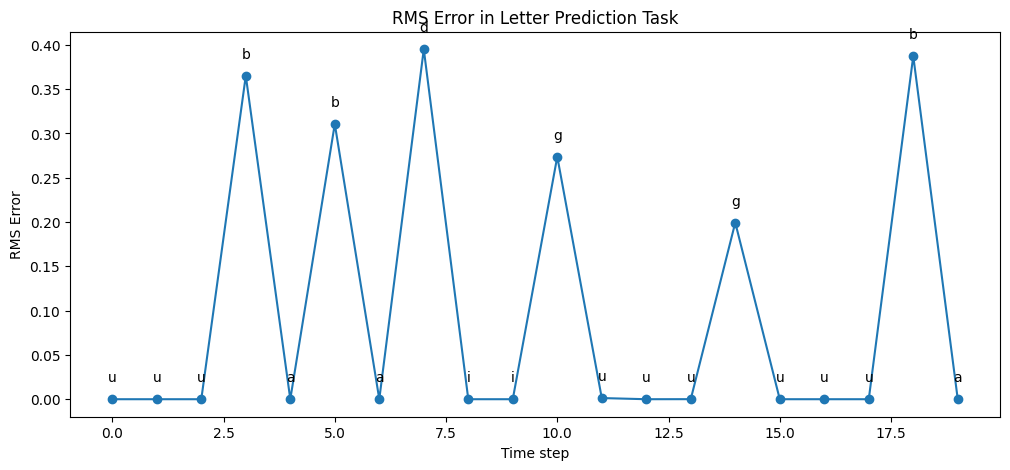

In [188]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

model.eval()

all_errors = []
all_labels = []

with torch.no_grad():
    X, y = next(iter(test_loader))

    X = X.to(device)
    y = y.to(device)

    logits = model(X)                     # [batch, seq_len, 6]
    probs = torch.softmax(logits, dim=-1) # [batch, seq_len, 6]

    y_onehot = F.one_hot(y, num_classes=6).float()  # [batch, seq_len, 6]

    rms_error = torch.sqrt(torch.mean((probs - y_onehot) ** 2, dim=-1))
    # shape: [batch, seq_len]

    # take first sample for plotting
    errors = rms_error[0].cpu().numpy()
    labels = y[0].cpu().tolist()

plt.figure(figsize=(12,5))
plt.plot(errors, marker='o')

for i, label_idx in enumerate(labels):
    plt.text(i, errors[i] + 0.02, idx_to_char[label_idx], ha='center')

plt.xlabel("Time step")
plt.ylabel("RMS Error")
plt.title("RMS Error in Letter Prediction Task")
plt.show()

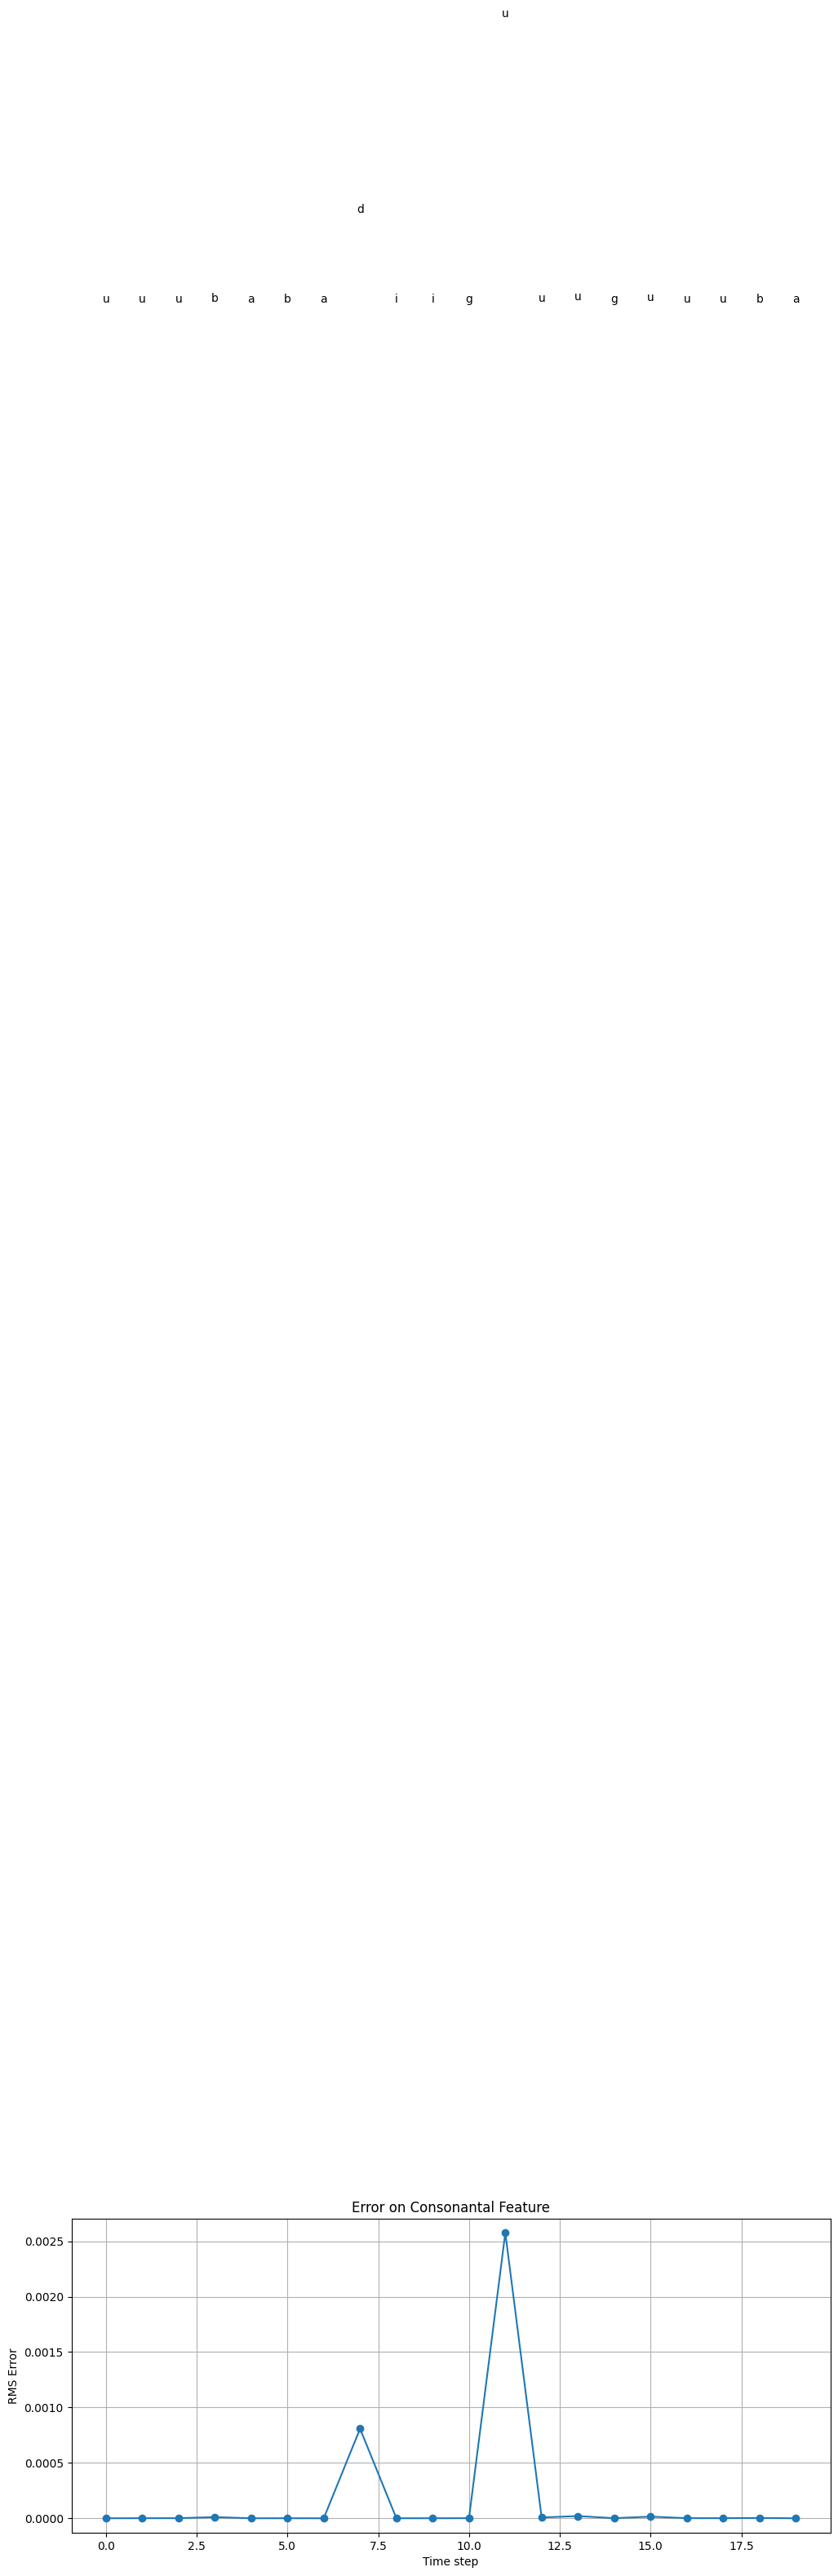

In [189]:
# consonantal feature: b,d,g are consonants
consonantal_target = torch.tensor([1, 1, 1, 0, 0, 0],device=device).float()

with torch.no_grad():
    X, y = next(iter(test_loader))

    X = X.to(device)
    y = y.to(device)

    logits = model(X)
    probs = torch.softmax(logits, dim=-1)

    # predicted probability of consonantal feature
    pred_consonantal = torch.matmul(probs, consonantal_target)   # [batch, seq_len]

    # true consonantal value
    true_consonantal = consonantal_target[y]        # [batch, seq_len]

    consonantal_error = (pred_consonantal - true_consonantal) ** 2

    errors = torch.sqrt(consonantal_error[0]).cpu().numpy()
    labels = y[0].cpu().tolist()

plt.figure(figsize=(12,5))
plt.plot(errors, marker='o')

for i, label_idx in enumerate(labels):
    plt.text(i, errors[i] + 0.02, idx_to_char[label_idx], ha='center')

plt.xlabel("Time step")
plt.ylabel("RMS Error")
plt.title("Error on Consonantal Feature")
plt.grid()
plt.show()

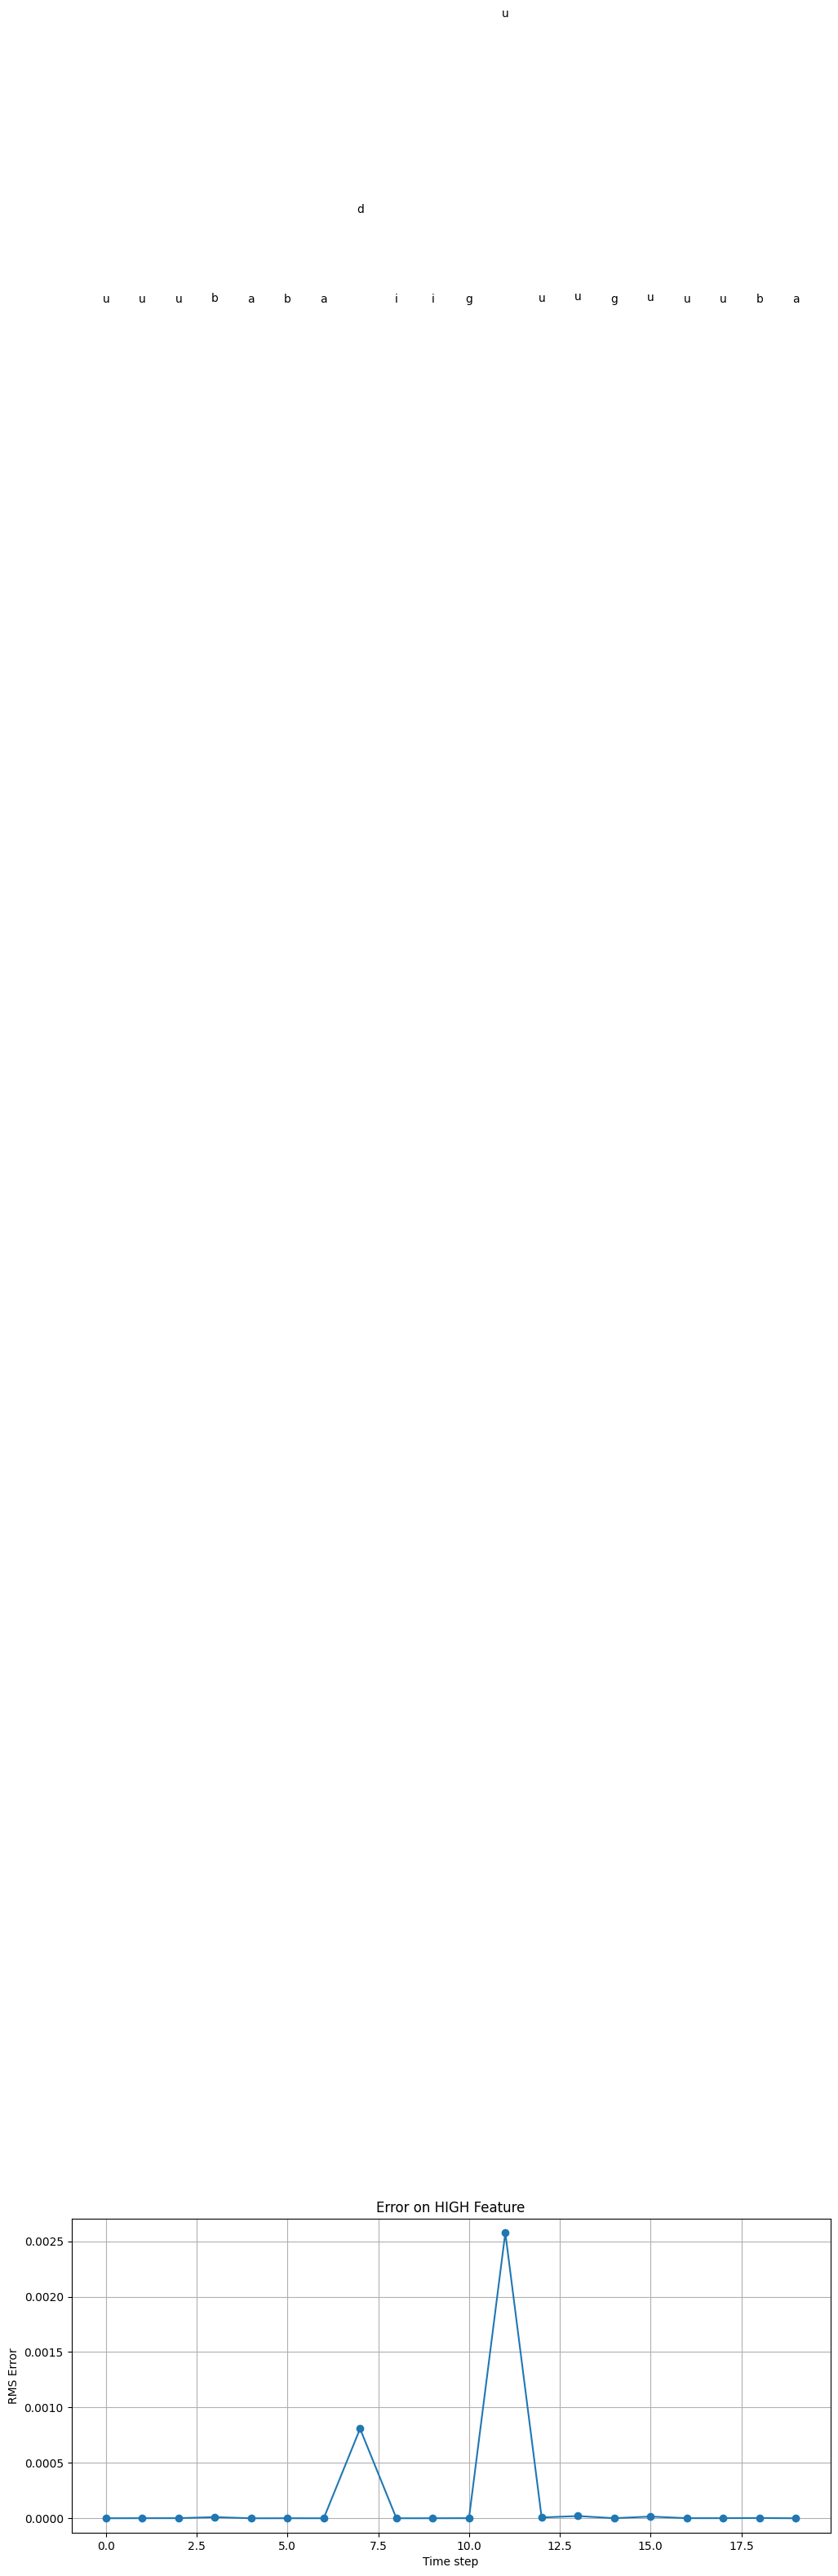

In [190]:
# simple HIGH feature definition
# b,d,g,a,i,u
# i and u are high vowels
high_target = torch.tensor(
    [0, 0, 0, 0, 1, 1],
    device=device
).float()

with torch.no_grad():
    X, y = next(iter(test_loader))

    X = X.to(device)
    y = y.to(device)

    logits = model(X)
    probs = torch.softmax(logits, dim=-1)

    pred_high = torch.matmul(probs, high_target)       # [batch, seq_len]
    true_high = high_target[y]            # [batch, seq_len]

    high_error = (pred_high - true_high) ** 2

    errors = torch.sqrt(high_error[0]).cpu().numpy()
    labels = y[0].cpu().tolist()

plt.figure(figsize=(12,5))
plt.plot(errors, marker='o')

for i, label_idx in enumerate(labels):
    plt.text(i, errors[i] + 0.02, idx_to_char[label_idx], ha='center')

plt.xlabel("Time step")
plt.ylabel("RMS Error")
plt.title("Error on HIGH Feature")
plt.grid()
plt.show()